## Ejercicio 3: Inspección visual de un producto

### Ficha PEAS
| Elemento | Descripción |
| :--- | :--- |
| **Percepción (S)** | Matriz NumPy de $5\times5$ píxeles que representa la imagen del producto ($0=$ píxel normal, $1=$ píxel defectuoso). |
| **Acciones (A)** | Aprobar producto, enviar a revisión manual o rechazar producto. |
| **Entorno (E)** | Cinta transportadora en la línea de producción y cámara de inspección industrial. |
| **Objetivo** | Garantizar el control de calidad reduciendo el paso de piezas defectuosas a la etapa de distribución. |
| **Medida de Desempeño (P)** | Porcentaje de productos defectuosos filtrados correctamente (precisión de inspección) y tiempo de procesamiento por pieza. |

### Justificación de las reglas
Las reglas se definen según la tolerancia a fallas en el proceso productivo: una pieza limpia ($0$ defectos) se aprueba de inmediato para no saturar la línea. Tolerancias bajas de $1$ a $3$ píxeles defectuosos se transfieren a revisión manual para evaluar si la pieza es recuperable o retrabajable, mientras que más de $3$ defectos comprometen severamente la calidad estructural, justificando su rechazo automático inmediato.

### Implementación del Agente

In [1]:
import numpy as np

def agente_inspeccion(imagen):
    """
    Percepción (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso)
    """
    # Contar la cantidad de píxeles defectuosos (valores igual a 1)
    defectos = np.sum(imagen == 1)
    
    if defectos == 0:
        return "aprobar", "Producto sin imperfecciones detectadas"
    elif defectos <= 3:
        return "revisión manual", f"Se detectaron {defectos} píxeles defectuosos (dentro del límite de tolerancia manual)"
    else:
        return "rechazar", f"Se detectaron {defectos} píxeles defectuosos (supera el límite permitido)"

### Simulación y Pruebas

--- EVALUACIÓN DE INSPECCIÓN VISUAL ---
Prueba 1 | Acción: 'aprobar' | Motivo: Producto sin imperfecciones detectadas
Prueba 2 | Acción: 'revisión manual' | Motivo: Se detectaron 2 píxeles defectuosos (dentro del límite de tolerancia manual)
Prueba 3 | Acción: 'revisión manual' | Motivo: Se detectaron 3 píxeles defectuosos (dentro del límite de tolerancia manual)
Prueba 4 | Acción: 'rechazar' | Motivo: Se detectaron 5 píxeles defectuosos (supera el límite permitido)


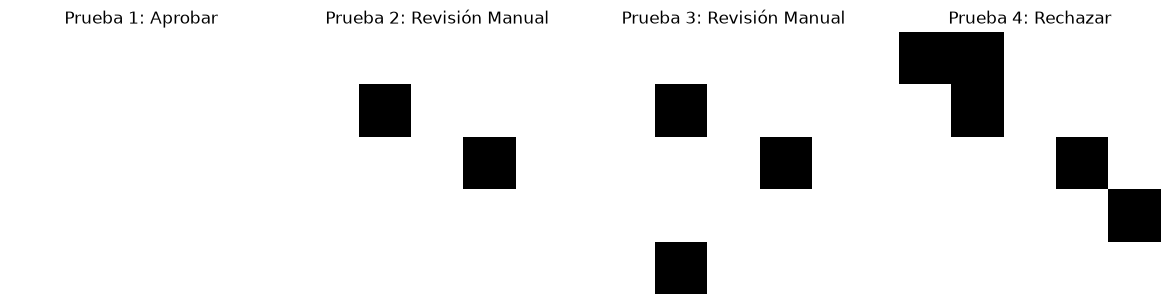

In [2]:
import matplotlib.pyplot as plt

# Definición de 4 casos de prueba (incluyendo casos límite)
imagenes_prueba = [
    # Caso 1: 0 defectos (Aprobar)
    np.zeros((5, 5), dtype=int),
    
    # Caso 2: 2 defectos (Revisión manual)
    np.array([
        [0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]
    ]),
    
    # Caso 3: 3 defectos - Caso borde (Revisión manual)
    np.array([
        [0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0]
    ]),
    
    # Caso 4: 5 defectos (Rechazar)
    np.array([
        [1, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0]
    ])
]

print("--- EVALUACIÓN DE INSPECCIÓN VISUAL ---")
plt.figure(figsize=(12, 3))

for i, img in enumerate(imagenes_prueba, 1):
    accion, motivo = agente_inspeccion(img)
    print(f"Prueba {i} | Acción: '{accion}' | Motivo: {motivo}")
    
    # Visualización opcional
    plt.subplot(1, 4, i)
    plt.imshow(img, cmap="gray_r")
    plt.title(f"Prueba {i}: {accion.title()}")
    plt.axis("off")

plt.tight_layout()
plt.show()